# Desafío 2 - Segmentación de Clientes

## 1. Introducción

En el presente análisis se aborda la segmentación de clientes del supermercado FreshMart utilizando técnicas de aprendizaje no supervisado.

El objetivo es identificar grupos de clientes con comportamientos de compra similares, con el fin de generar estrategias de marketing más personalizadas y efectivas. Para ello, se realizará un análisis de calidad de datos, una limpieza del conjunto de datos, la construcción de variables a nivel cliente y la aplicación de algoritmos de clustering.

Dado que la base entregada se encuentra a nivel de boleta, será necesario transformar la información para obtener variables representativas del comportamiento de cada cliente, como Recencia, Frecuencia y Valor Monetario (RFM).

## 2. Objetivo del análisis

El objetivo de este análisis es segmentar a los clientes en grupos homogéneos según su comportamiento de compra, utilizando variables derivadas de sus transacciones.

De esta forma, se busca identificar perfiles de clientes que permitan apoyar la toma de decisiones comerciales, tales como campañas de fidelización, promociones específicas y estrategias de reactivación.

# 3. Librerias

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore") ## Al usar muchas librerias, python podria agregar advertencias que no queremos.

## 3. Carga de datos

Se carga la base de datos entregada para realizar el análisis exploratorio, la limpieza y la posterior segmentación de clientes.

In [3]:
df = pd.read_excel("Retail_Invoices.xlsx")
df.head()

,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
0,536365,2010-12-01,17850,40,139.12,7
1,536366,2010-12-01,17850,12,22.20,2
2,536367,2010-12-01,13047,83,278.73,12
3,536368,2010-12-01,13047,15,70.05,4
4,536369,2010-12-01,13047,3,17.85,1


In [4]:
df.shape

(22190, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22190 entries, 0 to 22189
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    22190 non-null  object        
 1   InvoiceDate  22190 non-null  datetime64[ns]
 2   CustomerID   22190 non-null  int64         
 3   Quantity     22190 non-null  int64         
 4   price_total  22190 non-null  float64       
 5   StockCode    22190 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 1.0+ MB


## 4. Análisis de calidad de datos

En esta etapa se revisa la estructura de la base, los tipos de datos, los valores faltantes, duplicados y posibles valores anómalos.

Este análisis es importante porque la calidad de la información afecta directamente la segmentación final. El desafío pide explícitamente revisar y limpiar la data considerando valores faltantes, valores anómalos y un análisis exploratorio posterior.

In [6]:
df.describe(include="all") ## obligamos a agregar todas las columnas.

,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
count,22190,22190,22190.000000,22190.000000,22190.000000,22190.000000
unique,22190,NaN,NaN,NaN,NaN,NaN
top,C581569,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,2011-06-29 05:59:15.223073536,15238.498738,221.130599,374.045327,18.333889
min,NaN,2010-12-01 00:00:00,12346.000000,-80995.000000,-168469.600000,1.000000
25%,NaN,2011-03-29 00:00:00,13755.000000,30.000000,87.962500,3.000000
50%,NaN,2011-07-08 00:00:00,15136.000000,120.000000,241.505000,12.000000
75%,NaN,2011-10-10 00:00:00,16746.000000,254.000000,418.022500,24.000000
max,NaN,2011-12-09 00:00:00,18287.000000,80995.000000,168469.600000,542.000000


In [7]:
df.isnull().sum() #buscamos valores nulos

InvoiceNo      0
InvoiceDate    0
CustomerID     0
Quantity       0
price_total    0
StockCode      0
dtype: int64

In [8]:
df.duplicated().sum() #buscamos duplicados

np.int64(0)

In [9]:
df[df["Quantity"] <= 0].head() #revisamos valores extraños en quantity (cantidad menor o igual a 0)

,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
18536,C536379,2010-12-01,14527,-1,-27.50,1
18537,C536383,2010-12-01,15311,-1,-4.65,1
18538,C536391,2010-12-01,17548,-132,-141.48,7
18539,C536506,2010-12-01,17897,-6,-25.50,1
18540,C536543,2010-12-01,17841,-3,-3.80,2


In [10]:
df[df["price_total"] <= 0].head() #lo mismo pero en precio total

,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
2721,543599,2011-02-10,17560,16,0.0,1
11301,564651,2011-08-26,14646,576,0.0,4
12848,568384,2011-09-27,12748,1,0.0,1
17360,578841,2011-11-25,13256,12540,0.0,1
18536,C536379,2010-12-01,14527,-1,-27.5,1


In [11]:
df[df["StockCode"] <= 0].head() # stocks que sean menor que 0

,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode


### Observaciones

- Se revisan posibles valores nulos en las variables principales.
- Se inspeccionan registros con cantidades o montos no positivos, ya que podrían corresponder a devoluciones, anulaciones o errores.
- También se valida la consistencia de las variables numéricas antes de construir la segmentación.

## 5. Limpieza de datos

Para el proceso de segmentación se trabajará únicamente con transacciones válidas. Por esta razón, se eliminarán registros con cantidades o montos no positivos.

Además, se verificará que el identificador del cliente se encuentre disponible, ya que la segmentación se realizará a nivel cliente.

In [12]:
df_clean = df.copy() #creamos un nuevo df que será el df limpiado

In [13]:
# estandarizar nombre por comodidad
df_clean = df_clean.rename(columns={"CustomerID": "CustomerId"})

In [14]:
# eliminar nulos en cliente, si existieran
df_clean = df_clean.dropna(subset=["CustomerId"])

In [15]:
# dejar solo compras válidas
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["price_total"] > 0)]

In [16]:
# una buena practica es asegurar que el customer id sea entero, dado que puede que sea un string en futuras df's.
df_clean["CustomerId"] = df_clean["CustomerId"].astype(int)

In [17]:
df_clean.shape

(18532, 6)

In [18]:
df_clean.head()

,InvoiceNo,InvoiceDate,CustomerId,Quantity,price_total,StockCode
0,536365,2010-12-01,17850,40,139.12,7
1,536366,2010-12-01,17850,12,22.20,2
2,536367,2010-12-01,13047,83,278.73,12
3,536368,2010-12-01,13047,15,70.05,4
4,536369,2010-12-01,13047,3,17.85,1


Luego de la limpieza, la base queda compuesta solo por transacciones válidas para el análisis de clientes. Esta decisión busca evitar que devoluciones o montos negativos distorsionen la construcción de variables RFM y la posterior formación de clusters.

## 6. Análisis exploratorio de datos

A continuación, se analiza la distribución de las variables numéricas disponibles y su relación entre sí. Esto permite comprender mejor la estructura de la base y detectar posibles asimetrías o concentraciones de valores.

In [21]:
# definir límites ya que los outliers estan dificultando la vista
q_limit = df_clean["Quantity"].quantile(0.99)
p_limit = df_clean["price_total"].quantile(0.99)
s_limit = df_clean["StockCode"].quantile(0.99)

# filtrar solo para visualizar
df_plot = df_clean[
    (df_clean["Quantity"] <= q_limit) &
    (df_clean["price_total"] <= p_limit) &
    (df_clean["StockCode"] <= s_limit)
]

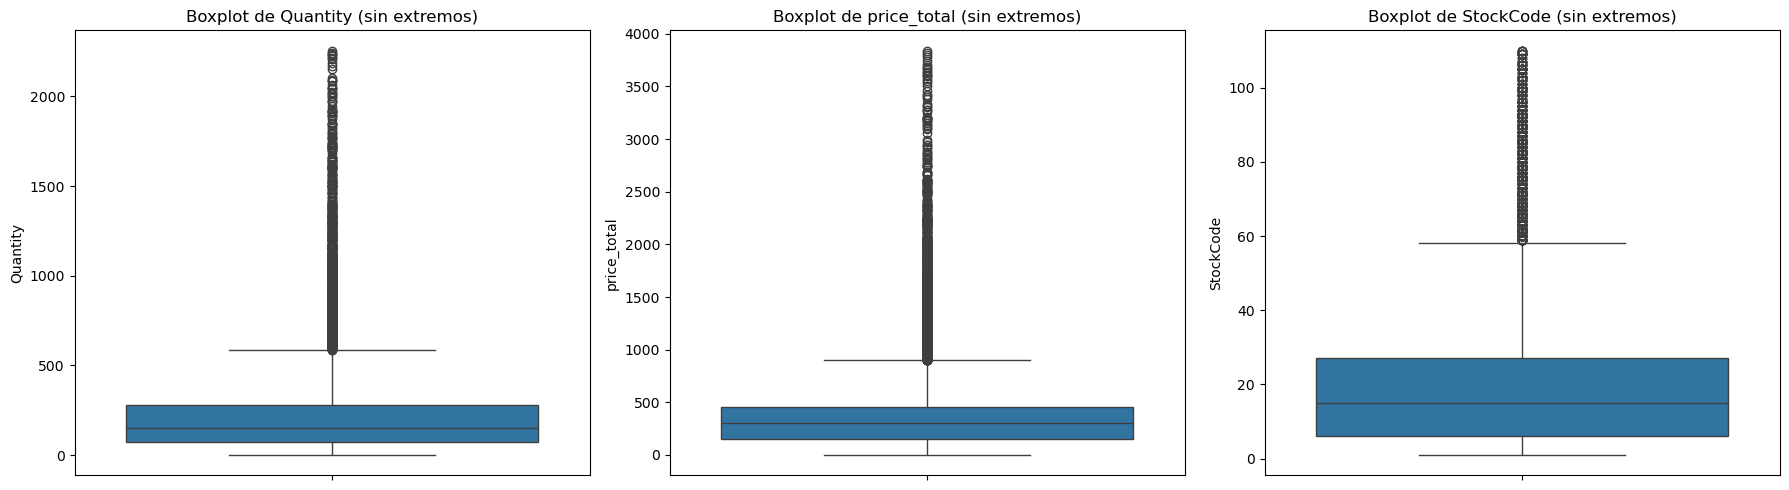

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df_plot["Quantity"], ax=axes[0])
axes[0].set_title("Boxplot de Quantity (sin extremos)")

sns.boxplot(y=df_plot["price_total"], ax=axes[1])
axes[1].set_title("Boxplot de price_total (sin extremos)")

sns.boxplot(y=df_plot["StockCode"], ax=axes[2])
axes[2].set_title("Boxplot de StockCode (sin extremos)")

plt.tight_layout()
plt.show()

In [24]:
#dado que cada fila es una boleta, en nuestro analisis queremos saber que es lo que compra el cliente
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [26]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

In [28]:
rfm = df_clean.groupby("CustomerId").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "count"),
    Monetary=("price_total", "sum")
).reset_index()

rfm.head(10)

,CustomerId,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,3,7,4310.00
2,12348,76,4,1797.24
3,12349,19,1,1757.55
4,12350,311,1,334.40
5,12352,37,8,2506.04
6,12353,205,1,89.00
7,12354,233,1,1079.40
8,12355,215,1,459.40
9,12356,23,3,2811.43


In [29]:
rfm.shape

(4338, 4)

In [30]:
rfm.describe()

,CustomerId,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,93.059474,4.272015,2054.266460
std,1721.808492,100.012264,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.750000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


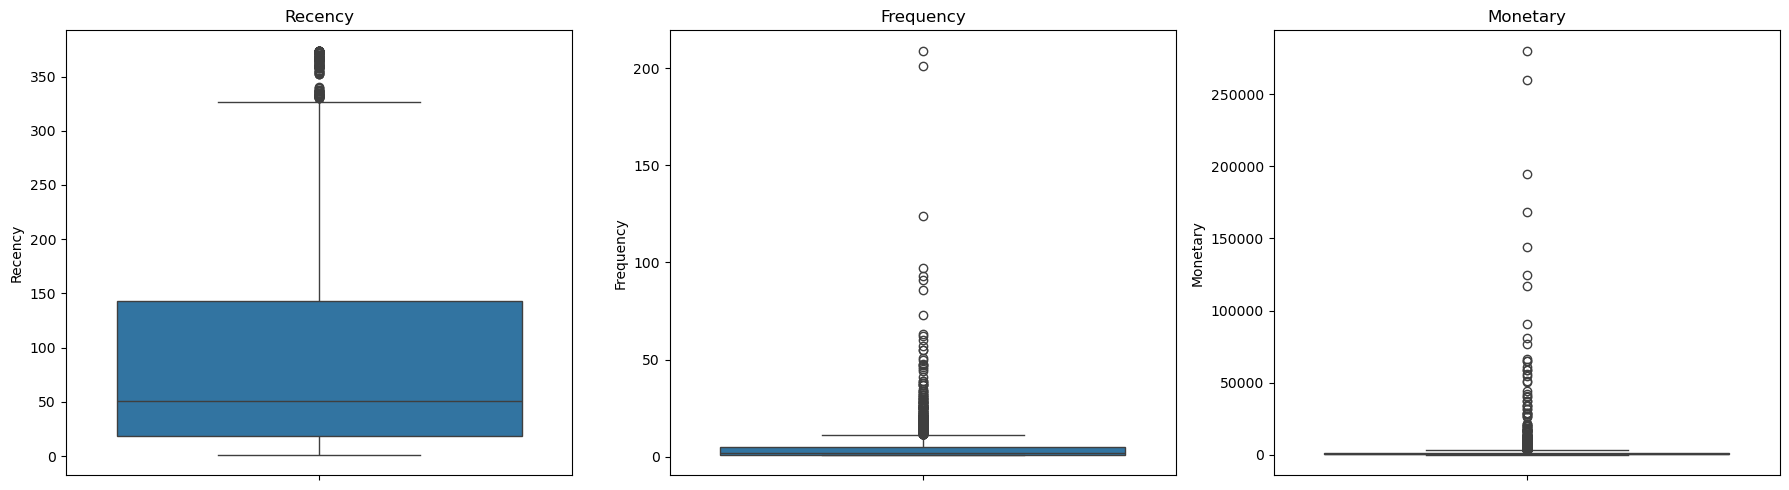

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.boxplot(y=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.boxplot(y=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

Se construyeron variables RFM a nivel cliente, permitiendo representar el comportamiento de compra de cada individuo. Estas variables son ampliamente utilizadas en segmentación de clientes, ya que capturan recencia, frecuencia y valor monetario de manera efectiva.

# 7- Transformación de los datos
dado que K-means no le gusta los valores outliers, tendremos que transformar el dataframe en uno mas amigable para él. de esta forma buscamos tener una mayor precision al momento de hacer el clustering.

## 7.1- Transformación logaritmica
Reduce el impacto de outliers, compactamos los valores grandes de los datos sin perder el orden de los mismos.

In [32]:
rfm_model = rfm.copy()

rfm_model["Recency_log"] = np.log1p(rfm_model["Recency"])
rfm_model["Frequency_log"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary_log"] = np.log1p(rfm_model["Monetary"])

rfm_model.head()

,CustomerId,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log
0,12346,326,1,77183.60,5.789960,0.693147,11.253955
1,12347,3,7,4310.00,1.386294,2.079442,8.368925
2,12348,76,4,1797.24,4.343805,1.609438,7.494564
3,12349,19,1,1757.55,2.995732,0.693147,7.472245
4,12350,311,1,334.40,5.743003,0.693147,5.815324


In [36]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_model[["Recency_log", "Frequency_log", "Monetary_log"]]
)

In [34]:
rfm_scaled[:5]

array([[ 1.47888429, -0.95521426,  3.70622476],
       [-1.89064214,  1.07442519,  1.41184341],
       [ 0.37233877,  0.38630445,  0.7164889 ],
       [-0.65915823, -0.95521426,  0.6987394 ],
       [ 1.4429545 , -0.95521426, -0.6189622 ]])

## Transformación de variables

Debido a la presencia de asimetría y valores extremos en las variables RFM, se aplicó una transformación logarítmica con el fin de reducir la influencia de los outliers y mejorar la distribución de los datos.

Posteriormente, se utilizó un escalado estándar (StandardScaler) para normalizar las variables. Esto es necesario ya que las variables originales presentan distintas magnitudes (por ejemplo, Monetary puede tener valores considerablemente mayores que Recency o Frequency).

Dado que los algoritmos de clustering como KMeans se basan en distancias, una variable con mayor escala puede dominar el cálculo y sesgar los resultados. El escalado permite que todas las variables contribuyan de manera equitativa en la formación de los clusters.

El uso de StandardScaler permite centrar las variables en torno a una media de 0 y una desviación estándar de 1, asegurando comparabilidad entre ellas y evitando sesgos en los algoritmos basados en distancia.

### Observaciones
Una vez transformada la base de datos desde un enfoque de boletas a clientes mediante variables RFM, se obtiene una representación más adecuada para realizar segmentación.

Posteriormente, se aplicó una transformación logarítmica para reducir el impacto de valores extremos, especialmente en la variable Monetary, manteniendo las relaciones entre los datos pero disminuyendo su dispersión.

Finalmente, se realizó un escalado de las variables utilizando StandardScaler, con el fin de igualar sus magnitudes y evitar que variables con valores mayores influyan desproporcionadamente en el algoritmo de clustering.

## 8. Selección del número óptimo de clusters

Una vez transformadas y escaladas las variables, se procede a determinar la cantidad adecuada de clusters para el modelo.

Dado que algoritmos como KMeans requieren definir previamente el número de grupos, se utilizarán dos criterios complementarios:

- **Método del codo**: permite analizar cómo disminuye la inercia a medida que aumenta el número de clusters.
- **Coeficiente de silueta**: evalúa qué tan bien separados y cohesionados están los grupos generados.

La decisión final se tomará considerando ambos indicadores, buscando un equilibrio entre interpretabilidad y calidad del agrupamiento.

### 8.1 Método del codo

El método del codo consiste en entrenar varios modelos KMeans con distintas cantidades de clusters y observar la evolución de la inercia.

La inercia mide qué tan cerca están los puntos de su centroide dentro de cada cluster. A medida que aumenta el número de clusters, la inercia disminuye. Sin embargo, llega un punto donde la mejora deja de ser significativa. Ese punto de quiebre se conoce como “codo”.

In [37]:
inertia = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

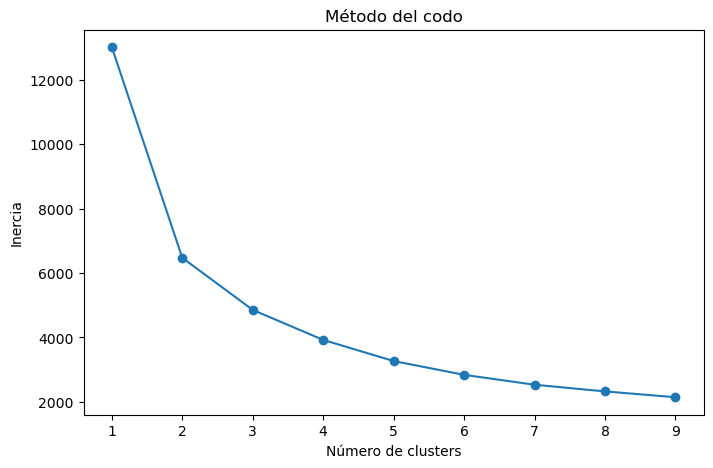

In [38]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

### 8.2 Coeficiente de silueta

El coeficiente de silueta permite medir la calidad del agrupamiento, considerando qué tan similares son los puntos dentro de su propio cluster y qué tan distintos son de los demás clusters.

Su valor varía entre -1 y 1:

- valores cercanos a **1** indican una buena separación entre clusters,
- valores cercanos a **0** indican superposición,
- valores negativos indican una mala asignación de observaciones.

In [39]:
silhouette_scores = []
k_values_sil = range(2, 10)

for k in k_values_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

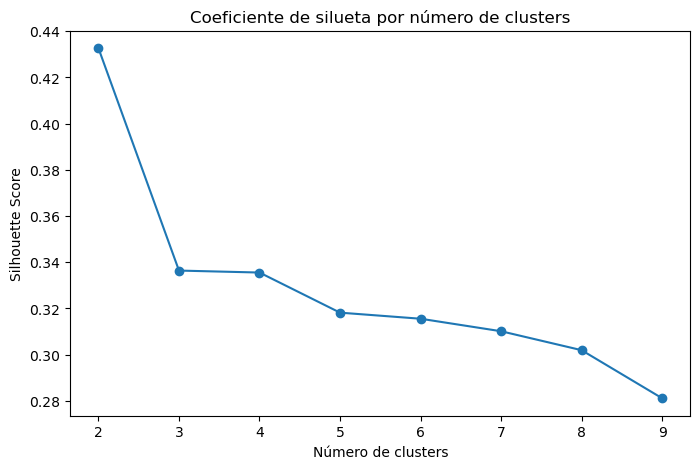

In [40]:
plt.figure(figsize=(8,5))
plt.plot(k_values_sil, silhouette_scores, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Coeficiente de silueta por número de clusters")
plt.show()

### 8.3 Selección final de K

A partir de los resultados obtenidos mediante el método del codo y el coeficiente de silueta, se seleccionará el número de clusters más adecuado para el análisis.

La elección final deberá considerar no solo el desempeño numérico del modelo, sino también la interpretabilidad de los segmentos resultantes.

In [41]:
resultados_k = pd.DataFrame({
    "k": list(k_values_sil),
    "silhouette_score": silhouette_scores
})

resultados_k

,k,silhouette_score
0,2,0.432624
1,3,0.336401
2,4,0.335547
3,5,0.318192
4,6,0.315561
5,7,0.310149
6,8,0.301952
7,9,0.281159


A partir del análisis realizado, se observa que el coeficiente de silueta alcanza su valor máximo en K=2. Sin embargo, una segmentación en solo dos grupos resulta poco útil desde el punto de vista del negocio, ya que limita la capacidad de diferenciación entre tipos de clientes.

Por otro lado, el método del codo sugiere que a partir de K=3 la mejora en la inercia comienza a disminuir de forma más gradual, indicando un punto adecuado de segmentación.

Considerando ambos criterios, se opta por seleccionar K=4, ya que permite un mayor nivel de segmentación sin deteriorar significativamente la calidad del clustering, manteniendo un equilibrio entre desempeño del modelo e interpretabilidad de los resultados.

## 9. Aplicación de algoritmos de clustering

### 9.1 KMeans

Se aplica el algoritmo KMeans utilizando el número de clusters previamente definido (K=4), con el objetivo de segmentar a los clientes en grupos homogéneos según sus variables RFM transformadas.

In [43]:
k_optimo = 4

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
rfm["Cluster_KMeans"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerId,Recency,Frequency,Monetary,Cluster_KMeans
0,12346,326,1,77183.60,3
1,12347,3,7,4310.00,2
2,12348,76,4,1797.24,3
3,12349,19,1,1757.55,0
4,12350,311,1,334.40,1


### 9.2 Clustering jerárquico aglomerativo

Se aplica un segundo algoritmo de clustering con el fin de comparar resultados y validar la consistencia de los segmentos obtenidos.

In [44]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=k_optimo)
rfm["Cluster_Agg"] = agg.fit_predict(rfm_scaled)

## 10. Evaluación de modelos

Se evalúan ambos modelos utilizando el coeficiente de silueta, con el objetivo de comparar la calidad de los clusters generados.

In [45]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(rfm_scaled, rfm["Cluster_KMeans"])
score_agg = silhouette_score(rfm_scaled, rfm["Cluster_Agg"])

print("Silhouette KMeans:", round(score_kmeans, 4))
print("Silhouette Agglomerative:", round(score_agg, 4))

Silhouette KMeans: 0.3355
Silhouette Agglomerative: 0.2746


## 11. Visualización de clusters

Se utiliza Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de los datos y visualizar los clusters en un plano bidimensional.

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

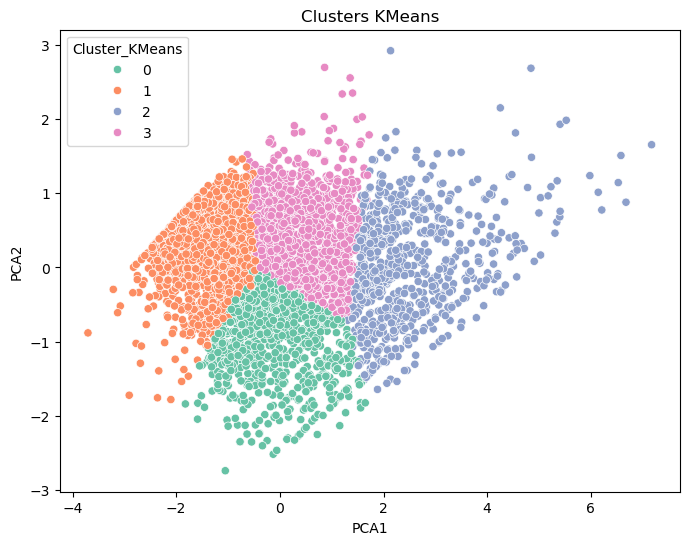

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster_KMeans", palette="Set2")
plt.title("Clusters KMeans")
plt.show()

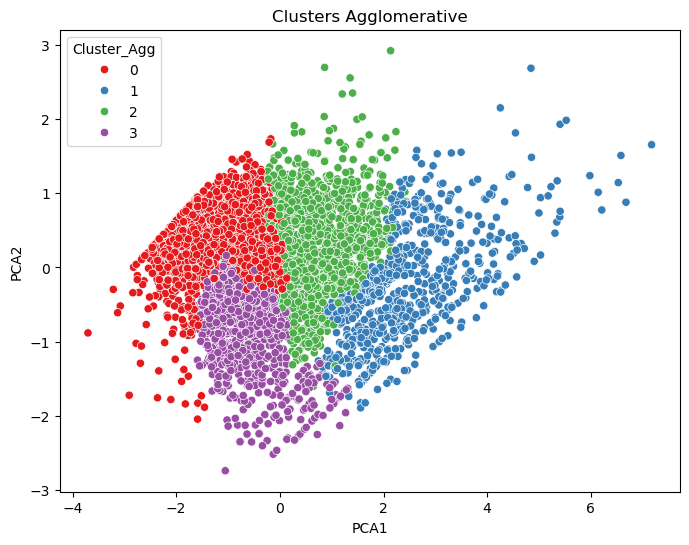

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster_Agg", palette="Set1")
plt.title("Clusters Agglomerative")
plt.show()

In [49]:
rfm.groupby("Cluster_KMeans")[["Recency", "Frequency", "Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Cluster_KMeans,,,
0,20.56,2.05,527.17
1,187.68,1.33,352.13
2,12.51,13.66,8037.21
3,69.11,4.13,1812.63


## Visualización de clusters

La visualización mediante PCA permite observar la distribución de los clientes en un espacio bidimensional, facilitando la interpretación de los clusters generados.

Se observa una separación clara entre los grupos, lo que indica que el modelo ha logrado identificar segmentos diferenciados de clientes. Sin embargo, existen zonas de solapamiento entre algunos clusters, lo cual es esperable dado el comportamiento continuo de las variables de consumo.

Además, se identifican puntos dispersos alejados de las concentraciones principales, lo que sugiere la presencia de clientes con comportamientos atípicos.

En general, la estructura observada respalda la validez de la segmentación obtenida mediante KMeans y clustering jerárquico.

## Interpretación de segmentos

A partir del análisis de las variables RFM, se identifican los siguientes segmentos de clientes:

**Cluster 2 – Clientes VIP**  
Este grupo presenta la menor recencia, junto con la mayor frecuencia y gasto. Corresponden a los clientes más valiosos del negocio, con alta actividad y contribución significativa en ingresos.

**Cluster 3 – Clientes leales**  
Clientes con frecuencia y gasto elevados, aunque menores que el grupo VIP. Representan un segmento estable que mantiene una relación constante con la empresa.

**Cluster 0 – Clientes ocasionales**  
Presentan baja frecuencia y gasto, aunque han realizado compras recientemente. Corresponden a clientes activos pero de bajo valor.

**Cluster 1 – Clientes perdidos**  
Este grupo presenta una alta recencia, lo que indica que hace mucho tiempo no realizan compras. Además, tienen baja frecuencia y gasto, lo que sugiere un bajo nivel de engagement con la empresa.

Estos segmentos permiten diseñar estrategias diferenciadas, tales como fidelización para clientes VIP, incentivos para clientes ocasionales y campañas de reactivación para clientes perdidos.